In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
df=pd.read_csv("Data/netflix_titles.csv")

In [20]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Analysis 1 : Movies vs TV Shows**

In [21]:
df.columns


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [22]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

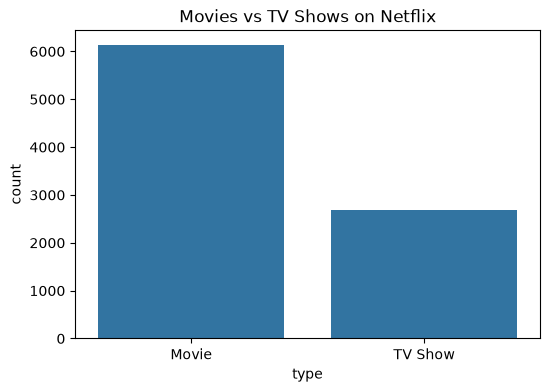

In [57]:
plt.figure(figsize=(6,4))
sns.countplot(data=df ,x='type')
plt.title("Movies vs TV Shows on Netflix")
plt.savefig("images/movies_vs_tvshows.png",dpi=300, bbox_inches='tight')
plt.show()

**Insight**



 Movies make up a significantly larger portion of Netflix's catelogue than TV Shows




In [24]:
df['date_added'].head()

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
Name: date_added, dtype: str

In [25]:
df['date_added'] = pd.to_datetime(df['date_added'] , errors ='coerce')

In [26]:
df['year_added'] = df['date_added'].dt.year

In [27]:
df['year_added'].value_counts().sort_index()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

**Analysis 2 : Netflix content added year wise**

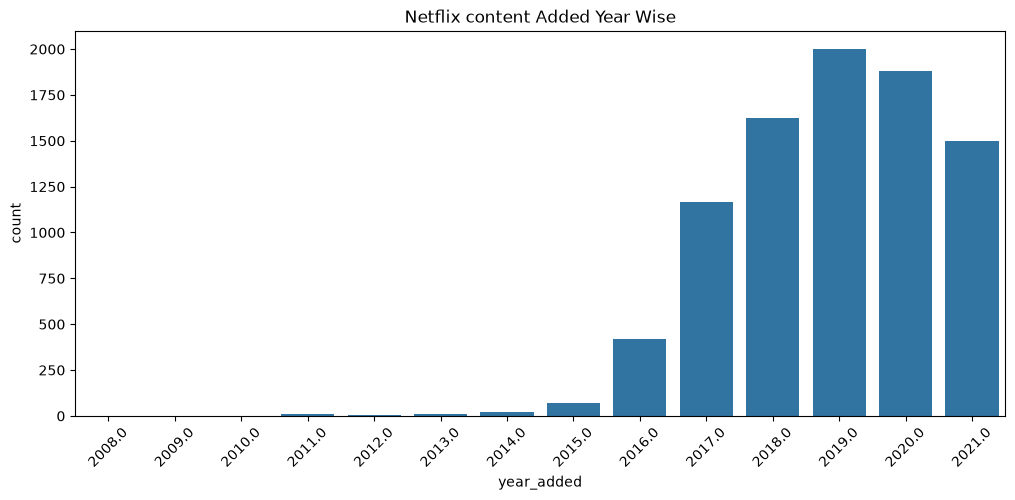

In [58]:
plt.figure(figsize=(12,5))
sns.countplot(
    data=df,
    x='year_added'
)

plt.xticks(rotation=45)

plt.title("Netflix content Added Year Wise")

plt.savefig("images/content_by_year.png", dpi=300, bbox_inches="tight")

plt.show()

In [29]:
df['country'].head()

0    United States
1     South Africa
2              NaN
3              NaN
4            India
Name: country, dtype: str

In [30]:
countries = df['country'].dropna()

In [31]:
countries = countries.str.split(',')

In [32]:
country_list = countries.explode()

In [33]:
country_counts = country_list.value_counts().head(10)

**Analysis 3: Top 10 Countries**

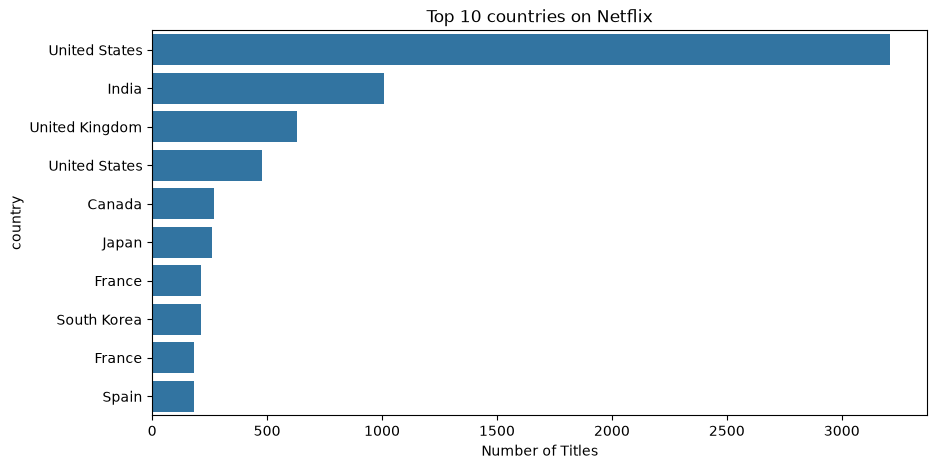

In [59]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)
plt.title("Top 10 countries on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("country")
plt.savefig("images/top_10_countries.png", dpi=300, bbox_inches="tight")

plt.show()

**Insight**

*   The United State has the highest number of titles on Netflix

*   India is one of the top contributors



In [35]:
df['listed_in'].head()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: str

In [36]:
genres = df['listed_in'].dropna()

In [37]:
genres = genres.str.split(',')

In [38]:
genre_list = genres.explode()

In [39]:
genre_counts = genre_list.value_counts().head(10)

**Analysis 4 : Top Genres**

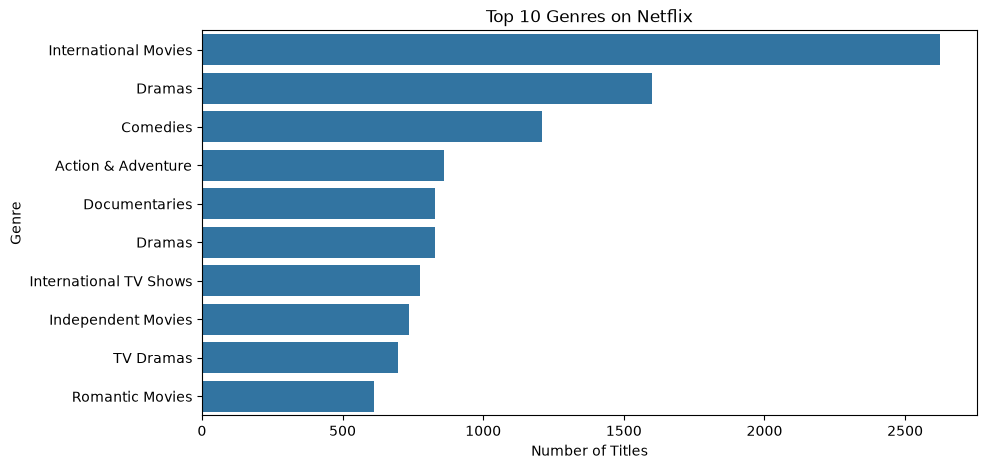

In [60]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.savefig("images/top_genres.png", dpi=300, bbox_inches="tight")

plt.show()

**Insight**

*   International Movies and Drama are among the most common genres.
*   Netflix offers content across a wide range of genres



In [41]:
movies = df[df['type'] =='Movie'].copy()

In [42]:
movies = movies.dropna(subset=['duration'])

In [43]:
movies['duration_minutes'] = (
    movies['duration'].str.replace(' min' ,'' ,regex=False).astype(int)
)

In [44]:
movies['duration'].head()

0      90 min
6      91 min
7     125 min
9     104 min
12    127 min
Name: duration, dtype: str

In [45]:
movies['duration_minutes'].head()

0      90
6      91
7     125
9     104
12    127
Name: duration_minutes, dtype: int64

**Analysis 5 : Movie Duration**

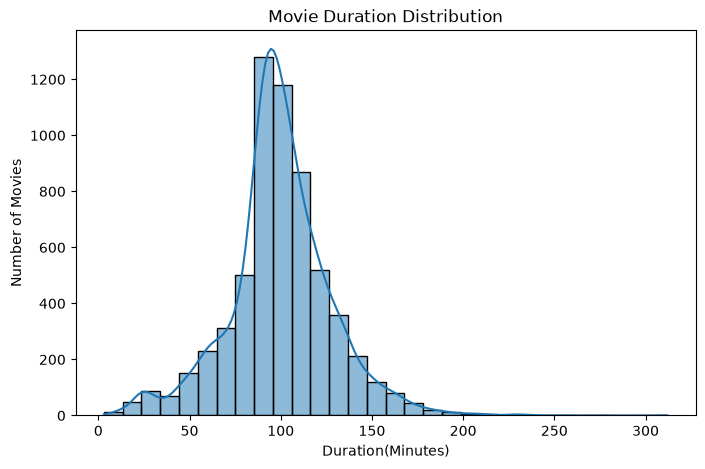

In [61]:
plt.figure(figsize=(8,5))

sns.histplot(
    movies['duration_minutes'],
    bins=30,
    kde=True
)
plt.title("Movie Duration Distribution")
plt.xlabel("Duration(Minutes)")
plt.ylabel("Number of Movies")
plt.savefig("images/Movie_Duration.png", dpi=300, bbox_inches="tight")

plt.show()

**Insight:**

*   Most Movies are between 80 and 120 minutes long.
*   very long movies are relatively uncommon



In [47]:
df['rating'].head(10)

0    PG-13
1    TV-MA
2    TV-MA
3    TV-MA
4    TV-MA
5    TV-MA
6       PG
7    TV-MA
8    TV-14
9    PG-13
Name: rating, dtype: str

In [48]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

**Analysis 6: Content Ratings**

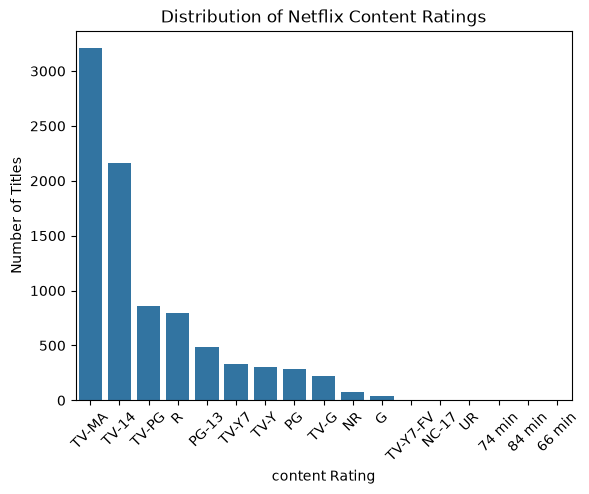

In [62]:


sns.countplot(data=df, x='rating' , order=df['rating'].value_counts().index )
plt.xticks(rotation=45)
plt.title("Distribution of Netflix Content Ratings")
plt.xlabel("content Rating")
plt.ylabel("Number of Titles")
plt.savefig("images/content_rating.png", dpi=300, bbox_inches="tight")

plt.show()

**Insight:**

*   TV-MA is the most common content rating
*   this suggests Netflix has a large collection of content aimed at mature audiance



In [50]:
content_by_year =(
    df.groupby(['year_added','type']).size().unstack()
)

**Analysis 7 : Content Added Over the Year**

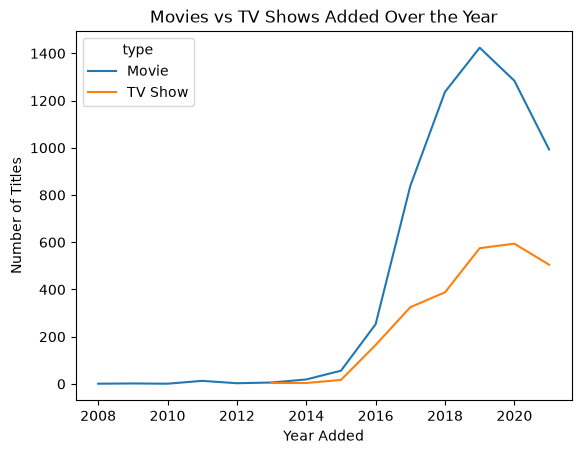

In [63]:
content_by_year.plot(kind='line')

plt.title("Movies vs TV Shows Added Over the Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.savefig("images/movies-TVshows(year).png", dpi=300, bbox_inches="tight")

plt.show()

**Insight:**

*   Netflix Added content rapidly after 2015
*   The catelogue grew significantly in the following year



**Analysis 8: Top Directors**

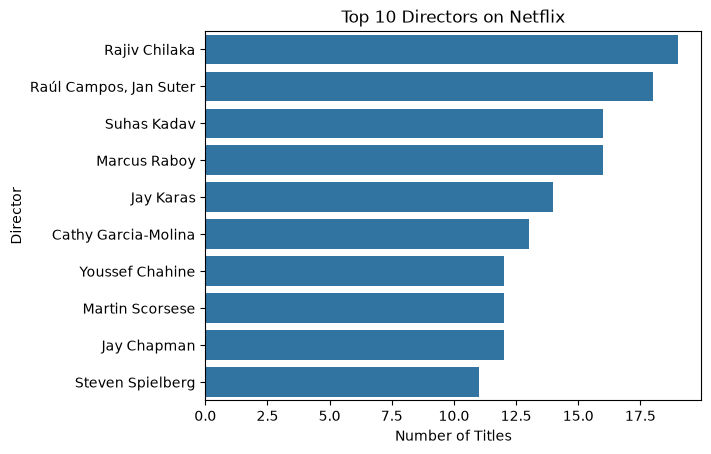

In [64]:
top_directors = (df['director'].dropna().value_counts().head(10))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.savefig("images/top-directors.png", dpi=300, bbox_inches="tight")

plt.show()

**Insight**

*   A small number of Directors have multiple titles on Netflix
*   Most Directors have only a few titles, indicating a diverse range of creators



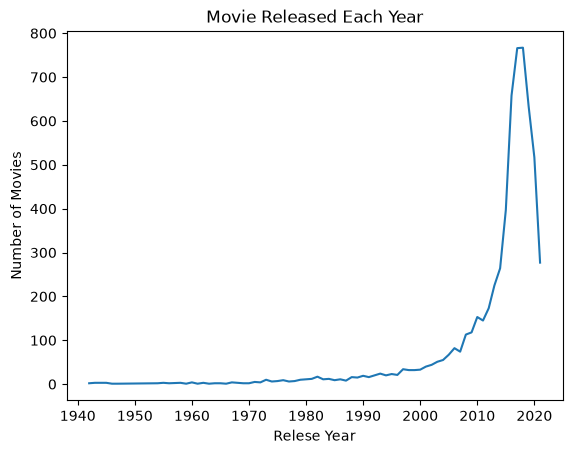

In [66]:
movie_release = (
    movies['release_year'].value_counts().sort_index()
)

sns.lineplot(
    x=movie_release.index,
    y=movie_release.values
)

plt.title("Movie Released Each Year")
plt.xlabel("Relese Year")
plt.ylabel("Number of Movies")
plt.savefig("images/movie-released-year.png", dpi=300, bbox_inches="tight")

plt.show()

In [54]:
longest_movies = (
    movies.sort_values(
        by='duration_minutes' , ascending=False
    )
)

longest_movies[
    ['title','duration_minutes']
].head(10)

,title,duration_minutes
4253,Black Mirror: Bandersnatch,312
717,Headspace: Unwind Your Mind,273
2491,The School of Mischief,253
2487,No Longer kids,237
2484,Lock Your Girls In,233
2488,Raya and Sakina,230
166,Once Upon a Time in America,229
7932,Sangam,228
1019,Lagaan,224
4573,Jodhaa Akbar,214


In [56]:
plt.savefig("images/movies_vs_tvshows.png",dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

**conclusion**

*   This project analysed the Netflix Movies and TV shows dataset using Python , Pandas , Matplotlib, and Seaborn

**Key Findings**

1.   Movies outnumber TV shows on Netflix.
2.   TV-MA is the most common content rating.
3.   The United-States contributes the highest number of titles.
4.   Most Movies have durations between 80-120 minutes.
5.   Netflix experienced rapid growth in content additions after 2015.
6.   The Platform offers a diverse colection of genres and directors




